# **Tamires Rezende (CNN Clássica)**

In [6]:
import os
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

In [7]:
DATASET_PATH = "aumentado"  # <--- ALTERE AQUI
IMG_SIZE = 128
EPOCHS = 20
BATCH_SIZE = 32

In [8]:
def load_data(path):
    images, labels = [], []
    classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    class_map = {cls: i for i, cls in enumerate(classes)}
    
    print(f"[Tamires] Carregando imagens de {len(classes)} classes...")
    for cls in classes:
        cls_dir = os.path.join(path, cls)
        for img_name in os.listdir(cls_dir):
            try:
                img_path = os.path.join(cls_dir, img_name)
                img = cv2.imread(img_path)
                if img is None: continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(img)
                labels.append(class_map[cls])
            except Exception: pass
            
    return np.array(images), np.array(labels), len(classes), classes

In [9]:
def build_cnn_model(num_classes):
    """
    Arquitetura baseada na filosofia de CNNs sequenciais (VGG-style)
    adaptada para imagens estáticas (substituindo a CNN 3D da tese original).
    """
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        # Bloco Convolucional 1
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        # Bloco Convolucional 2
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        # Bloco Convolucional 3
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        # Camadas Densas
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5), # Regularização importante citada na tese
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

[Tamires] Carregando imagens de 25 classes...
[Tamires] Iniciando treinamento da CNN...
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.0390 - loss: 3.3071 - val_accuracy: 0.0389 - val_loss: 3.2163
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.0857 - loss: 3.1716 - val_accuracy: 0.2212 - val_loss: 2.9062
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.1886 - loss: 2.7636 - val_accuracy: 0.3540 - val_loss: 2.3483
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.3161 - loss: 2.2879 - val_accuracy: 0.4796 - val_loss: 1.8239
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.4310 - loss: 1.8330 - val_accuracy: 0.5646 - val_loss: 1.7078
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.5161 - loss: 1.5519 - val_accuracy: 0.6496 - val_loss: 1.2404
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.6027 - loss: 1.2483 - val_accuracy: 0.6779 - val_loss: 1.1085
Epoch 8/20
71/71

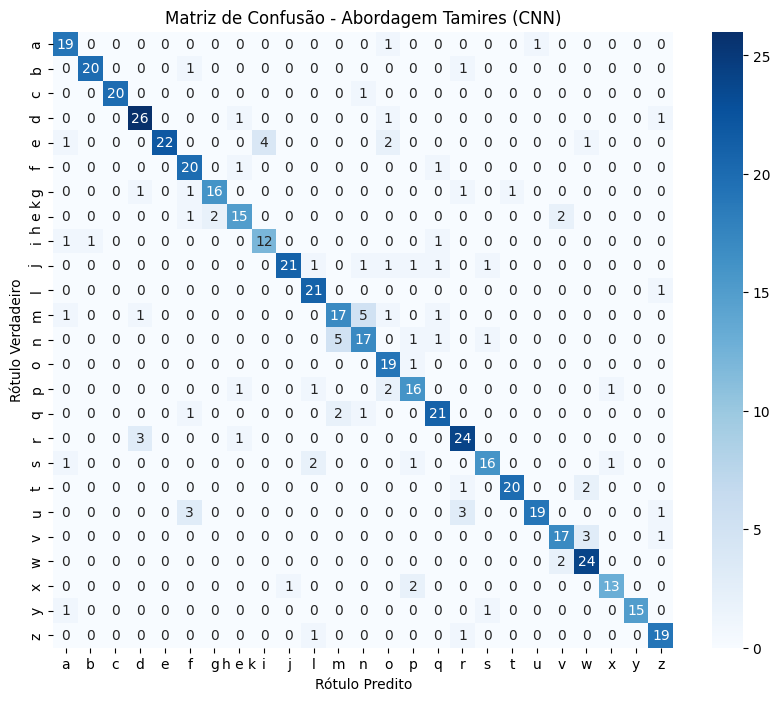

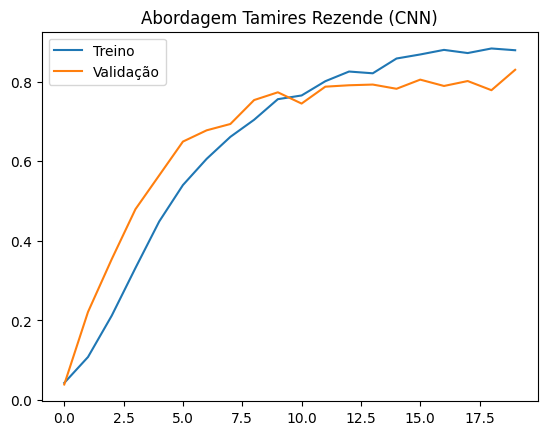

In [10]:
# 1. Carregar Dados
X, y_raw, num_classes, class_names = load_data(DATASET_PATH)

# 2. Pré-processamento
X = X.astype('float32') / 255.0
y_cat = to_categorical(y_raw, num_classes) # Labels no formato One-Hot (para treino)

X_train, X_test, y_train, y_test_cat = train_test_split(X, y_cat, test_size=0.2, random_state=42)
# y_test_raw para comparação com a predição (necessário para a matriz)
y_test_raw = np.argmax(y_test_cat, axis=1) 

# 3. Treino
model = build_cnn_model(num_classes)
print("[Tamires] Iniciando treinamento da CNN...")
history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_test, y_test_cat))

# 4. Avaliação
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\n>>> Acurácia Total (Abordagem Tamires): {acc*100:.2f}%")

# --- NOVA SEÇÃO: ANÁLISE DETALHADA COM MATRIZ DE CONFUSÃO ---

# Fazer predições no conjunto de teste
y_pred_cat = model.predict(X_test)
y_pred_raw = np.argmax(y_pred_cat, axis=1) # Converte predições One-Hot de volta para índices

# Gerar e imprimir o Relatório de Classificação
print("\n--- Relatório de Classificação por Classe ---")
print(classification_report(y_test_raw, y_pred_raw, target_names=class_names))

# Gerar a Matriz de Confusão
cm = confusion_matrix(y_test_raw, y_pred_raw)

# Plotar a Matriz de Confusão 
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Abordagem Tamires (CNN)')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Predito')
plt.show()

# Plotar Acurácia de Treino/Validação
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Abordagem Tamires Rezende (CNN)')
plt.legend()
plt.show()

In [11]:
model.save('modelo_tamires.keras')